# POLONAISE UHDM limits: excluded $(m_\text{DM}, \alpha_n)$ regions

**Private.** The 95% CL exclusion limits for ultraheavy dark matter coupling
to neutrons through a finite-range Yukawa mediator, from the levitated-magnet
impulse search, with the observed candidate events handled by the public
[`optimum_interval`](https://github.com/tunnell/optimum_interval) package (no
background model needed).

**Input:** the `EVENTS` array of reconstructed kick momenta (here one random
toy candidate); replacing that array with data is the only change needed.
**Output:** the figures below and the machine-readable
`limit_contour_data.npz` (every surface and contour, so nothing needs
digitizing).

Mediator ranges $\lambda$ = 2 m down to 2 µm in decade steps (plus the
analytic massless limit); couplings up to $\alpha_n = 1$; masses up to the
Planck mass. Fiducials: sensor radius $R_\text{eff}$ = 200 µm, threshold
$q_\text{th}$ = 8.4 TeV, two-week exposure, SHM halo with atmospheric
attenuation, and this species taken as $f_X$ = 0.1 of the local dark matter
density.

Companion notebooks: [`02_methodology.ipynb`](02_methodology.ipynb) (the physics
and statistics pipeline, validations) and
[`03_understanding.ipynb`](03_understanding.ipynb) (why the exclusion regions look
the way they do). The heavy computations are cached (`scan7_<tag>.npz`,
`scan_lambda.npz`, `flux_maps.npz`, generated by `scripts/` on a many-core
node through the same `luhdm.rate` module this notebook imports); delete a
cache and the affected cell recomputes a coarse version inline.


In [1]:
# ===== CONFIG: which sensor mode this notebook analyses =====
MODE_NUMBER = 1   # 1, 2, or 3

%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import atmosphere, config, cross_section, efficiency, halo, limits, units

R_eff = config.R_EFF             # 200 um
Q_THRESH = config.Q_THRESH          # 0.1 TeV analysis threshold
EFF = efficiency.make_efficiency(MODE_NUMBER)   # per-mode detection efficiency
T_TOTAL = 3600 * 470      # 2 weeks in seconds
CONFIDENCE = 0.95
M_PLANCK = 1.22e19               # GeV

# the seven planned mediator ranges, largest first. The family is ordered in
# lambda, so it gets a sequential blue-to-green ramp (truncated viridis:
# monotone lightness survives black-and-white printing and is colorblind-safe,
# and it contains no red, which is reserved for the events / 95% contour).
_TAGS = ["2m", "2cm", "2mm", "200um", "20um", "10um", "2um"]
_LAMBS = [2.0, 2e-2, 2e-3, 2e-4, 2e-5, 1e-5, 2e-6]
_RAMP = plt.cm.viridis(np.linspace(0.02, 0.78, len(_TAGS)))
LAMBDAS = list(zip(_TAGS, _LAMBS, [tuple(c) for c in _RAMP]))
HIDE = {"2um"}                   # loaded and exported, but not drawn
LAMB_REF = 2e-4                  # reference range for the detailed figures

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    if lamb_m >= 1:
        si = f"{lamb_m:.0f} m"
    elif lamb_m >= 1e-2:
        si = f"{lamb_m * 1e2:.0f} cm"
    elif lamb_m >= 1e-3:
        si = f"{lamb_m * 1e3:.0f} mm"
    else:
        si = f"{lamb_m * 1e6:.3g} µm"
    return rf"$\lambda$ = {si}"


def mphi_label(lamb_m, unit="eV"):
    # mediator mass m_phi = hbar c / lambda
    m_phi = 1.0 / units.conv_m2pGeV(lamb_m)
    if unit == "eV":
        m_phi *= 1e9
    e = int(np.floor(np.log10(m_phi)))
    return rf"$m_\phi$ = ${m_phi / 10**e:.1f}\times10^{{{e}}}$ {unit}"


def range_legend(lamb_m):
    # legend entry: range and the corresponding mediator mass (in eV)
    return lamb_label(lamb_m).split(" = $")[0] + ", " + mphi_label(lamb_m)


# SI-prefix milestones on a DM-mass axis (masses in GeV; names in eV prefixes)
MASS_MILESTONES = [(1e6, "PeV"), (1e9, "EeV"), (1e12, "ZeV"), (1e15, "YeV")]

def mark_mass_milestones(ax, m_lo, m_hi):
    import matplotlib.patheffects as _pe
    for m_gev, name in MASS_MILESTONES:
        if m_lo < m_gev < m_hi:
            ax.axvline(m_gev, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
            txt = ax.text(m_gev, 0.015, f" {name}", color="#555555",
                          fontsize=9, ha="left", va="bottom", rotation=90,
                          transform=ax.get_xaxis_transform())
            txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                                  _pe.Normal()])


import os as _os
for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)

def save_figure(fig, name, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number prefix
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)


RNG_SHM = np.random.default_rng(20260702)  # passed to the luhdm samplers         # luhdm samplers use legacy np.random
print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"R_eff = {R_eff * 1e6:.0f} um   f_X = {config.F_X}")

N_n = 2.51e+20   q_th = 100 GeV   R_eff = 200 um   f_X = 0.1


## Input: the event list

The observed impulses live in [`data.txt`](data.txt) (one impulse per line,
in eV, `#` comments allowed). **Replace that file with the reconstructed
kicks from data and rerun; nothing else changes.** If the file is absent, a
single toy candidate just above threshold is drawn and written there.


In [2]:
DATA = Path(f"data_mode{MODE_NUMBER}.txt")
if not DATA.exists():
    rng = np.random.default_rng(20260702)
    toy_ev = 1e9 * 10 ** rng.uniform(np.log10(Q_THRESH),
                                     np.log10(3 * Q_THRESH), size=1)
    np.savetxt(DATA, toy_ev, fmt="%.18e", header=(
        "Observed impulse candidates for the POLONAISE UHDM search.\n"
        "One impulse per line, in eV (momentum transfer q reconstructed\n"
        "from the sensor ringdown); 1 GeV = 1e9 eV.\n"
        "This file is the analysis input: edit it and rerun the notebooks."))
    print(f"wrote toy candidate to {DATA}")
EVENTS = np.atleast_1d(np.loadtxt(DATA)) / 1e9   # eV -> GeV
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [   861.     947.6   1245.8   1305.    1339.1   1348.2   1377.3   1443.1
   1461.    1478.9   1486.3   1520.7   1544.4   1615.5   1629.    1659.9
   1661.3   1678.5   1729.4   1733.5   1761.1   1795.1   1814.2   1842.3
   1872.7   2013.4   2018.3   2021.5   2033.7   2037.5   2055.5   2092.5
   2137.1   2147.5   2215.6   2245.    2366.2   2467.8   2508.7   2527.9
   2575.3   2611.2   2716.3   2842.9   2862.    2969.8   2987.9   3235.9
   3252.4   3338.4   3509.6   5705.1   6749.    6761.9   6905.1   6913.2
   6979.5   9482.1  12790.7  18563.1  18622.2  25153.3  38608.5  78392.1
 113305.8 126524.3]


In [3]:
import os
os.environ["TQDM_DISABLE"] = "1"

from luhdm import rate

# lazy cross-section handles: only cache-miss fallbacks ever build them
class _LazyXsec(dict):
    def __init__(self, lamb):
        self._lamb = lamb
        self._built = None
    def _get(self):
        if self._built is None:
            self._built = rate.make_xsec(self._lamb)
        return self._built
    def __getitem__(self, k):
        return self._get()[k]

XSEC = {tag: _LazyXsec(lamb) for tag, lamb, _ in LAMBDAS}
XS_MASSLESS = rate.make_xsec(None)   # analytic; free to build
v_i_samples = atmosphere.sample_shm(int(1e5), rng=RNG_SHM)  # for inline fallbacks

## The scans

One scan per mediator range from `scripts/scan_grid.py`, each a full
$(m_\text{DM}, \alpha_n)$ grid carrying the `extremeness` (the optimum-interval
statistic; its meaning is unpacked in
[`02_methodology.ipynb`](02_methodology.ipynb)), the expected counts, and the
transit counts.


In [4]:
SCANS = {}
ALL_TAGS = LAMBDAS + [("massless", None, "k")]
for tag, lamb, color in ALL_TAGS:
    f = Path(f"computation_cache/mode{MODE_NUMBER}/scan7_{tag}.npz")
    if not f.exists():
        print(f"{f} missing; skipping {tag}")
        continue
    d = np.load(f)
    assert np.allclose(d["events"], EVENTS), f"{f}: different event list!"
    if "mode" in d.files:
        assert int(d["mode"]) == MODE_NUMBER, f"{f}: cache mode {int(d['mode'])} != {MODE_NUMBER}"
    if lamb is not None:
        assert np.isclose(float(d["lamb"]), lamb), f"{f}: lambda mismatch"
    else:
        assert bool(d["massless"]), f"{f}: expected a --massless scan"
    SCANS[tag] = dict(
        ms=d["ms"], alphas_n=d["alphas_n"], extremeness=d["extremeness"],
        counts=d["counts"], n_transit=np.maximum(d["n_transit"], 0.0),
        lamb=lamb, color=color)
    # (n_transit clip: the KDE tail can oscillate slightly negative below the
    # kinematic floor)
print(f"loaded {len(SCANS)}/{len(ALL_TAGS)} scans "
      f"({len(LAMBDAS)} ranges + massless)")

REF_TAG = "200um"
if REF_TAG not in SCANS:
    # coarse inline fallback for the reference range
    ms = np.logspace(6.6, np.log10(M_PLANCK), 19)
    alphas_n = np.logspace(-8.5, 0.0, 30)
    counts = np.zeros((alphas_n.size, ms.size))
    extremeness = np.zeros((alphas_n.size, ms.size))
    N_T = np.zeros((alphas_n.size, ms.size))
    table = limits.new_table(seed=20260702)
    xs_ref = XSEC[REF_TAG]
    t0 = time.time()
    for im, m in enumerate(ms):
        for ia, alpha_n in enumerate(alphas_n):
            v_min = Q_THRESH / m / 10
            v_f_samples = atmosphere.compute_v_f_distribution(
                alpha_n, LAMB_REF, m, v_i_samples, v_min=v_min, n_grid=80)
            f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
            qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
            diff_rate = rate.differential_rate_trapz(qs, alpha_n, m, f_v_f, xs_ref, eff=EFF)
            extremeness[ia, im], counts[ia, im] = limits.extremeness_and_mu(
                table, EVENTS, qs, diff_rate, T_TOTAL)
            N_T[ia, im] = rate.expected_transits(alpha_n, m, f_v_f, xs_ref, T_TOTAL)
    SCANS[REF_TAG] = dict(ms=ms, alphas_n=alphas_n, extremeness=extremeness,
                          counts=counts, n_transit=N_T, lamb=LAMB_REF,
                          color="#d62728")
    print(f"inline scan ({REF_TAG}): {time.time() - t0:.0f}s")

REF = SCANS[REF_TAG]

computation_cache/mode1/scan7_2m.npz missing; skipping 2m
computation_cache/mode1/scan7_2cm.npz missing; skipping 2cm
computation_cache/mode1/scan7_2mm.npz missing; skipping 2mm
computation_cache/mode1/scan7_20um.npz missing; skipping 20um
computation_cache/mode1/scan7_10um.npz missing; skipping 10um
computation_cache/mode1/scan7_2um.npz missing; skipping 2um
loaded 2/8 scans (7 ranges + massless)


## Results

### The reference range, $\lambda = R_\text{eff}$ = 200 µm

Solid: the 95% CL optimum-interval contour given `EVENTS`. Dashed: the
$\langle N\rangle = 3$ zero-event contour (the old rule) from the same
`counts` surface. The excluded region is an island; each edge is explained in
"Understanding" below.

Note the dashed contour pokes out past the red one near the floor and the
left edge: there the (narrow) kinematic window contains the observed kick, so
the honest one-event limit is weaker than the zero-event rule, which simply
does not apply once there is a candidate. Where the window excludes the event
the two coincide.


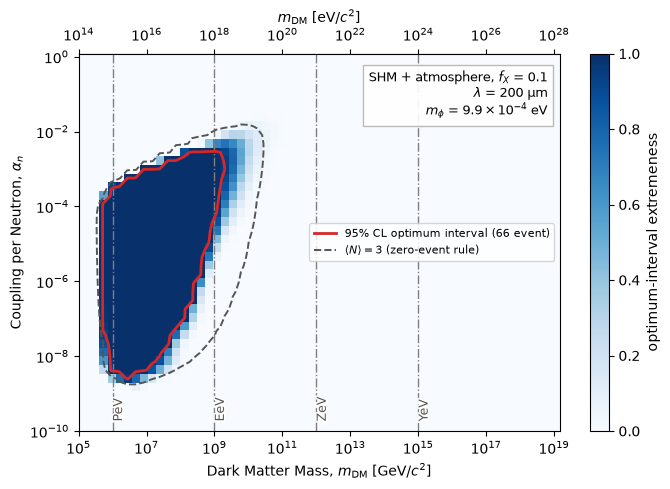

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(REF["ms"], REF["alphas_n"], REF["extremeness"],
                     cmap="Blues", vmin=0, vmax=1, shading="auto")
fig.colorbar(mesh, ax=ax, label="optimum-interval extremeness")
cs95 = ax.contour(REF["ms"], REF["alphas_n"], REF["extremeness"],
                  levels=[CONFIDENCE], colors="#d62728", linewidths=2)
cs3 = ax.contour(REF["ms"], REF["alphas_n"], REF["counts"], levels=[3.0],
                 colors="#555555", linewidths=1.4, linestyles="--")
ax.plot([], [], color="#d62728", lw=2,
        label=f"{CONFIDENCE:.0%} CL optimum interval ({EVENTS.size} event)")
ax.plot([], [], color="#555555", lw=1.4, ls="--",
        label=r"$\langle N\rangle = 3$ (zero-event rule)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
mark_mass_milestones(ax, REF["ms"].min(), M_PLANCK)
sec = ax.secondary_xaxis("top", functions=(lambda x: x * 1e9,
                                            lambda x: x / 1e9))
sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
ax.text(0.975, 0.955,
        "SHM + atmosphere, $f_X$ = 0.1\n"
        + lamb_label(LAMB_REF) + "\n"
        + mphi_label(LAMB_REF),
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(loc="center right", fontsize=8)
fig.tight_layout()
save_figure(fig, "01_excluded_region")

### All seven ranges

The 95% CL contours for the seven planned ranges, with the single toy
candidate and atmospheric attenuation everywhere. Five ranges exclude; the
momentum cap $\tilde q_\text{max} = K_1(\xi)$ organizes the family:

- **Shared floor at long range.** The 2 m, 2 cm, and 2 mm islands share the
  same coupling floor, $\alpha_n \approx 2.0\times10^{-8}$ (Coulomb regime);
  200 µm and 20 µm pay the momentum-cap penalty ($3.3\times10^{-8}$ and
  $3.5\times10^{-5}$).
- **High-mass endpoints ladder by $\sim100\times$ per decade of $\lambda$**
  (reach saturation, $\sigma_\text{sat} \sim \lambda^2$, vs the falling
  number density $f_X/m$): $3.0\times10^{7}$ GeV (20 µm, now a sliver),
  $1.1\times10^{10}$ (200 µm), $1.6\times10^{12}$ (2 mm), $1.4\times10^{14}$
  (2 cm), $6.3\times10^{17}$ (2 m). Even the 2 m island closes well below the
  Planck mass.
- **The massless analytic line (black dashed) is the $\lambda\to\infty$
  ideal.** Its exclusion continues through the Planck-mass edge of the grid:
  flux quantization never closes an uncapped Coulomb reach. Its floor,
  $\alpha_n \approx 1.3\times10^{-8}$, sits below even the 2 m island's,
  because at floor couplings the 2 m momentum cap
  ($\tilde q_\text{max} = K_1(\xi)$) already bites; the sensor cross section
  is the analytic $2\pi\alpha^2/(v^2q^3)$, with the atmospheric Coulomb log
  regulated at 2 m.
- **The three shortest ranges exclude nothing or almost nothing.** The 20 µm
  island survives only as a sliver around $3\times10^{7}$ GeV; the 10 µm
  saturated rate tops out at $\mu \approx 2.4$ and 2 µm at 0.4, below the
  one-event 95% bar. Honest nulls, not plotting gaps; the 2 µm case is
  omitted from the figures but kept in the scans and the data export.


 200um: m in [5.2e+05, 2.0e+09] GeV, alpha_n down to 2.5e-09
massless: m in [3.0e+05, 1.2e+19] GeV, alpha_n down to 8.5e-10


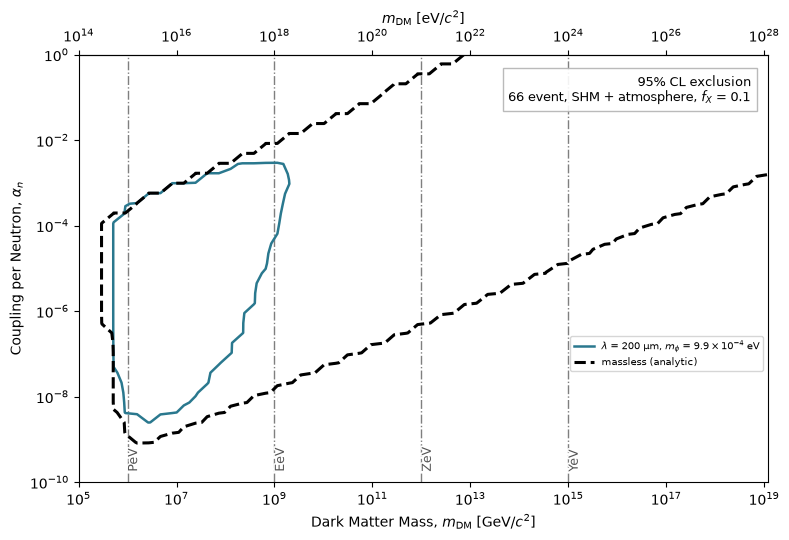

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
CS95 = {}
for tag, lamb, color in ALL_TAGS:
    if tag not in SCANS or tag in HIDE:
        continue
    s = SCANS[tag]
    style = dict(linestyles="--", linewidths=2.2) if lamb is None else \
        dict(linewidths=1.8)
    lab = ("massless (analytic)" if lamb is None
           else range_legend(lamb))
    if (s["extremeness"] >= CONFIDENCE).any():
        CS95[tag] = ax.contour(s["ms"], s["alphas_n"], s["extremeness"],
                               levels=[CONFIDENCE], colors=color, **style)
        ax.plot([], [], color=color, lw=style["linewidths"],
                ls="--" if lamb is None else "-", label=lab)
    else:
        ax.plot([], [], color=color, lw=1.8, label=lab + " (no exclusion)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(REF["ms"].min(), M_PLANCK)
ax.set_ylim(REF["alphas_n"].min(), 1.0)
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
mark_mass_milestones(ax, REF["ms"].min(), M_PLANCK)
sec = ax.secondary_xaxis("top", functions=(lambda x: x * 1e9,
                                            lambda x: x / 1e9))
sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
n_shown = len([t for t, _, _ in LAMBDAS if t not in HIDE])
ax.text(0.975, 0.955,
        f"{CONFIDENCE:.0%} CL exclusion\n"
        f"{EVENTS.size} event, SHM + atmosphere, $f_X$ = 0.1",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(loc="center right", bbox_to_anchor=(1.0, 0.30), fontsize=7)
fig.tight_layout()
save_figure(fig, "01_all_mediator_ranges")

for tag, lamb, color in ALL_TAGS:
    if tag not in SCANS:
        continue
    s = SCANS[tag]
    excl = s["extremeness"] >= CONFIDENCE
    if excl.any():
        m_ex = np.broadcast_to(s["ms"], excl.shape)[excl]
        a_ex = np.broadcast_to(s["alphas_n"][:, None], excl.shape)[excl]
        print(f"{tag:>6}: m in [{m_ex.min():.1e}, {m_ex.max():.1e}] GeV, "
              f"alpha_n down to {a_ex.min():.1e}")
    else:
        print(f"{tag:>6}: no exclusion (max p = {s['extremeness'].max():.2f}, "
              f"max mu = {s['counts'].max():.2f})")

### Sensitivity vs mediator range at the best mass

Fixing $m_\text{DM}$ at the most sensitive mass (the deepest point of the
reference-range coupling floor, $1.8\times10^{7}$ GeV) and scanning the
mediator range against the coupling, across all seven planned ranges (2 µm to
2 m) with the same coupling grid as the mass scans. The excluded band is
bounded below by the statistics floor, which deepens with range and levels
off at the Coulomb value $\alpha_n \approx 2\times10^{-8}$ once
$\lambda \gtrsim$ mm (the momentum cap stops mattering), and above by the
atmospheric ceiling at $\alpha_n \approx 10^{-3}$, which is nearly
$\lambda$-independent (atmospheric stopping is set by scattering off nuclei,
not by the sensor). The band **pinches off at $\lambda \approx 20$ µm**,
where the rising floor meets the ceiling: at this mass, mediators with
shorter range are untestable at any coupling, which is exactly why the 10 µm
and 2 µm channels return nulls in the seven-range figure above.


best mass m_DM = 2.71e+06 GeV (floor alpha_n = 2.49e-09 at 200um)


inline lambda scan: 126s (cache with scripts/scan_lambda.py)


/tmp/ipykernel_610698/692959943.py:60: RuntimeWarning: divide by zero encountered in divide
  lambda x: 1e9 / units.conv_m2pGeV(1.0) / x))


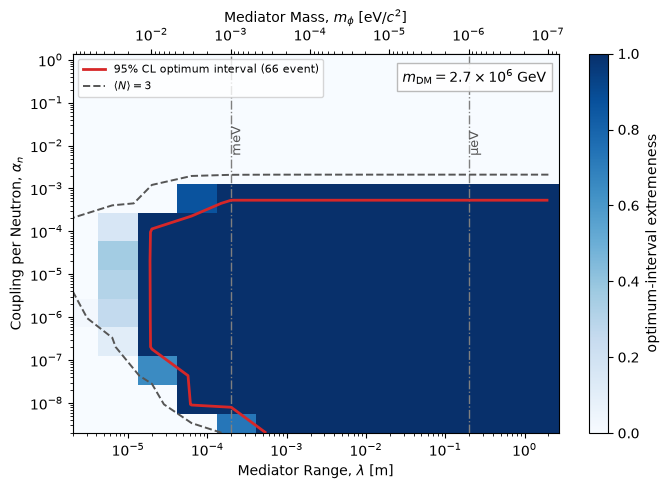

In [7]:
# best mass: where the reference-range coupling floor is deepest
floor = np.array([REF["alphas_n"][REF["extremeness"][:, im] >= CONFIDENCE].min()
                  if (REF["extremeness"][:, im] >= CONFIDENCE).any() else np.nan
                  for im in range(REF["ms"].size)])
M_BEST = float(REF["ms"][np.nanargmin(floor)])
print(f"best mass m_DM = {M_BEST:.2e} GeV "
      f"(floor alpha_n = {np.nanmin(floor):.2e} at {REF_TAG})")

LSCAN = Path(f"computation_cache/mode{MODE_NUMBER}/scan_lambda.npz")
if LSCAN.exists():
    dl = np.load(LSCAN)
    assert np.allclose(dl["events"], EVENTS)
    if not np.isclose(float(dl["m_dm"]), M_BEST, rtol=0.05):
        print(f"note: cache fixed m_DM = {float(dl['m_dm']):.2e} GeV")
    lambs_l, alphas_l = dl["lambs"], dl["alphas_n"]
    p_l, mu_l = dl["extremeness"], dl["counts"]
    m_fixed = float(dl["m_dm"])
    print(f"loaded {LSCAN}: {lambs_l.size} ranges x {alphas_l.size} couplings")
else:
    # coarse inline fallback through the same rate module
    lambs_l = np.geomspace(2e-6, 2.0, 13)
    alphas_l = np.logspace(-8.7, 0.0, 14)
    m_fixed = M_BEST
    p_l = np.zeros((alphas_l.size, lambs_l.size))
    mu_l = np.zeros_like(p_l)
    table_l = limits.new_table(seed=20260702)
    t0 = time.time()
    for il, lamb in enumerate(lambs_l):
        xs_l = rate.make_xsec(lamb, force_ln=True)
        for ia, a in enumerate(alphas_l):
            v_min = Q_THRESH / m_fixed / 10
            v_f_samples = atmosphere.compute_v_f_distribution(
                a, lamb, m_fixed, v_i_samples, v_min=v_min, n_grid=80)
            f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
            qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
            dr = rate.differential_rate_trapz(qs, a, m_fixed, f_v_f, xs_l, eff=EFF)
            p_l[ia, il], mu_l[ia, il] = limits.extremeness_and_mu(
                table_l, EVENTS, qs, dr, T_TOTAL)
    print(f"inline lambda scan: {time.time() - t0:.0f}s "
          "(cache with scripts/scan_lambda.py)")

fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(lambs_l, alphas_l, p_l, cmap="Blues", vmin=0, vmax=1,
                     shading="auto")
fig.colorbar(mesh, ax=ax, label="optimum-interval extremeness")
CS95_L = ax.contour(lambs_l, alphas_l, p_l, levels=[CONFIDENCE],
                    colors="#d62728", linewidths=2)
ax.contour(lambs_l, alphas_l, mu_l, levels=[3.0], colors="#555555",
           linewidths=1.4, linestyles="--")
ax.plot([], [], color="#d62728", lw=2,
        label=f"{CONFIDENCE:.0%} CL optimum interval ({EVENTS.size} event)")
ax.plot([], [], color="#555555", lw=1.4, ls="--",
        label=r"$\langle N\rangle = 3$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Mediator Range, $\lambda$ [m]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
secax = ax.secondary_xaxis(
    "top", functions=(lambda x: 1e9 / units.conv_m2pGeV(x),
                      lambda x: 1e9 / units.conv_m2pGeV(1.0) / x))
secax.set_xlabel(r"Mediator Mass, $m_\phi$ [eV/$c^2$]")

# SI-prefix milestones that land inside the plotted mass window
SI_EV = [(1e-24, "yeV"), (1e-21, "zeV"), (1e-18, "aeV"), (1e-15, "feV"),
         (1e-12, "peV"), (1e-9, "neV"), (1e-6, "µeV"), (1e-3, "meV"),
         (1.0, "eV")]
lam_of_ev = lambda m_ev: 1e9 / units.conv_m2pGeV(1.0) / m_ev  # lambda [m]
for m_ev, name in SI_EV:
    lam_mark = lam_of_ev(m_ev)
    if lambs_l.min() < lam_mark < lambs_l.max():
        ax.axvline(lam_mark, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
        ax.text(lam_mark, 0.72, f" {name}", color="#555555", fontsize=9,
                ha="left", va="bottom", rotation=90,
                transform=ax.get_xaxis_transform())
e_b = int(np.floor(np.log10(m_fixed)))
ax.text(0.975, 0.96,
        rf"$m_{{\rm DM}} = {m_fixed / 10**e_b:.1f}\times10^{{{e_b}}}$ GeV",
        transform=ax.transAxes, ha="right", va="top", fontsize=10,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
save_figure(fig, "01_sensitivity_vs_range")

## Machine-readable output

Everything on the plots, written to `limit_contour_data.npz` so nobody ever
has to digitize a figure: per-range grids and surfaces (keys suffixed by the
range tag), the event list, the 95% contours as NaN-separated
(m, alpha_n) polylines, and the Planck-range understanding maps.


In [8]:
def contour_polyline(cs):
    # all segments of a single-level contour as one NaN-separated (N, 2) array
    parts = []
    for seg in cs.allsegs[0]:
        parts.append(seg)
        parts.append(np.full((1, 2), np.nan))
    return np.vstack(parts) if parts else np.empty((0, 2))


out = dict(events=EVENTS, t_total=T_TOTAL, confidence=CONFIDENCE,
           lambdas=np.array([l for _, l, _ in LAMBDAS]))
for tag, lamb, color in ALL_TAGS:
    if tag not in SCANS:
        continue
    s = SCANS[tag]
    out[f"ms_{tag}"] = s["ms"]
    out[f"alphas_n_{tag}"] = s["alphas_n"]
    out[f"extremeness_{tag}"] = s["extremeness"]
    out[f"counts_{tag}"] = s["counts"]
    out[f"n_transit_{tag}"] = s["n_transit"]
    if tag in CS95:
        out[f"contour_95_{tag}"] = contour_polyline(CS95[tag])
out["contour_n3_200um"] = contour_polyline(cs3)
out["lambda_scan_lambs"] = lambs_l
out["lambda_scan_alphas"] = alphas_l
out["lambda_scan_extremeness"] = p_l
out["lambda_scan_counts"] = mu_l
out["lambda_scan_m_dm"] = m_fixed
if len(CS95_L.allsegs[0]):
    out["contour_95_lambda"] = contour_polyline(CS95_L)
MAPS = Path("computation_cache/flux_maps.npz")
if MAPS.exists():   # transit/reach maps (see understanding.ipynb)
    dmap = np.load(MAPS)
    out["nt_map_ms"] = dmap["ms_map"]
    out["nt_map_alphas"] = dmap["al_map"]
    out["nt_map_massless"] = dmap["nt_massless"]
    out["nt_map_finite"] = dmap["nt_finite"]
    out["b_map_massless"] = dmap["b_massless"]
    out["b_map_finite"] = dmap["b_finite"]
np.savez(f"computation_cache/mode{MODE_NUMBER}/limit_contour_data.npz", **out)
d = np.load(f"computation_cache/mode{MODE_NUMBER}/limit_contour_data.npz")
print("limit_contour_data.npz:", len(d.files), "arrays")
print(sorted(d.files))

limit_contour_data.npz: 29 arrays
['alphas_n_200um', 'alphas_n_massless', 'b_map_finite', 'b_map_massless', 'confidence', 'contour_95_200um', 'contour_95_lambda', 'contour_95_massless', 'contour_n3_200um', 'counts_200um', 'counts_massless', 'events', 'extremeness_200um', 'extremeness_massless', 'lambda_scan_alphas', 'lambda_scan_counts', 'lambda_scan_extremeness', 'lambda_scan_lambs', 'lambda_scan_m_dm', 'lambdas', 'ms_200um', 'ms_massless', 'n_transit_200um', 'n_transit_massless', 'nt_map_alphas', 'nt_map_finite', 'nt_map_massless', 'nt_map_ms', 't_total']


## Notes

- **Data**: replace `EVENTS` and rerun. More candidates only move the
  extremeness surfaces; the machinery is untouched.
- The scans and all figure inputs flow through **`luhdm/rate.py`**, shared
  with the `scripts/`, so notebook and cluster runs cannot drift.
- With zero events the 95% contour coincides with the
  $\langle N\rangle \simeq 3$ rule by construction (dashed line in the first
  figure).
